In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
# Leitura do arquivo

arquivo = 'photon1E15_array'

df = pl.read_csv(arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("count"))

df

column_1,split_column,TRIG,count
str,list[str],str,i64
"""TRIG1 1""","[""TRIG1"", ""1""]","""TRIG1""",1
"""TRIG2 0""","[""TRIG2"", ""0""]","""TRIG2""",0
"""TRIG3 1""","[""TRIG3"", ""1""]","""TRIG3""",1
"""TRIG4 1""","[""TRIG4"", ""1""]","""TRIG4""",1
"""TRIG5 1""","[""TRIG5"", ""1""]","""TRIG5""",1
"""TRIG6 3""","[""TRIG6"", ""3""]","""TRIG6""",3
"""TRIG7 3""","[""TRIG7"", ""3""]","""TRIG7""",3
"""TRIG8 5""","[""TRIG8"", ""5""]","""TRIG8""",5
"""TRIG9 2""","[""TRIG9"", ""2""]","""TRIG9""",2


In [147]:
import re
def formatar_string(s):
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', s)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return s

name = formatar_string(arquivo)
name

'Photon 1E15'

In [148]:
# Transformação das contagens de partículas em listas e na média de contagens

df2 = df.group_by('TRIG').agg(pl.col("count")).sort(
    pl.col("TRIG").str.extract(r"TRIG([0-9]*)", 1).cast(int)
)
df2 = df2.with_columns(mean_count = pl.col('count').list.mean())  
df2

TRIG,count,mean_count
str,list[i64],f64
"""TRIG1""","[1, 0, … 1]",0.66
"""TRIG2""","[0, 1, … 0]",0.67
"""TRIG3""","[1, 0, … 0]",0.73
"""TRIG4""","[1, 1, … 2]",0.89
"""TRIG5""","[1, 0, … 3]",1.24
"""TRIG6""","[3, 1, … 1]",1.32
"""TRIG7""","[3, 1, … 3]",1.29
"""TRIG8""","[5, 2, … 2]",1.44
"""TRIG9""","[2, 0, … 0]",0.83


In [149]:
# Lista dos TRIGS com valores da média 

trigs = df2['mean_count'].to_list()

In [150]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize) * spacing
        y_det[index] = (i - halfGridSize) * spacing
        areas[index] = area
        index += 1

print("x_det:", x_det)
print("y_det:", y_det)
print("areas:", areas)


x_det: [-50. -40. -30. -20. -10.   0.  10.  20.  30.  40. -50. -40. -30. -20.
 -10.   0.  10.  20.  30.  40. -50. -40. -30. -20. -10.   0.  10.  20.
  30.  40. -50. -40. -30. -20. -10.   0.  10.  20.  30.  40. -50. -40.
 -30. -20. -10.   0.  10.  20.  30.  40. -50. -40. -30. -20. -10.   0.
  10.  20.  30.  40. -50. -40. -30. -20. -10.   0.  10.  20.  30.  40.
 -50. -40. -30. -20. -10.   0.  10.  20.  30.  40. -50. -40. -30. -20.
 -10.   0.  10.  20.  30.  40. -50. -40. -30. -20. -10.   0.  10.  20.
  30.  40.]
y_det: [-50. -50. -50. -50. -50. -50. -50. -50. -50. -50. -40. -40. -40. -40.
 -40. -40. -40. -40. -40. -40. -30. -30. -30. -30. -30. -30. -30. -30.
 -30. -30. -20. -20. -20. -20. -20. -20. -20. -20. -20. -20. -10. -10.
 -10. -10. -10. -10. -10. -10. -10. -10.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.  10.  10.  10.  10.  10.  10.  10.  10.  10.  10.
  20.  20.  20.  20.  20.  20.  20.  20.  20.  20.  30.  30.  30.  30.
  30.  30.  30.  30.  30.  30.  40.  40.  40.  40. 

Text(0, 0.5, 'y (m)')

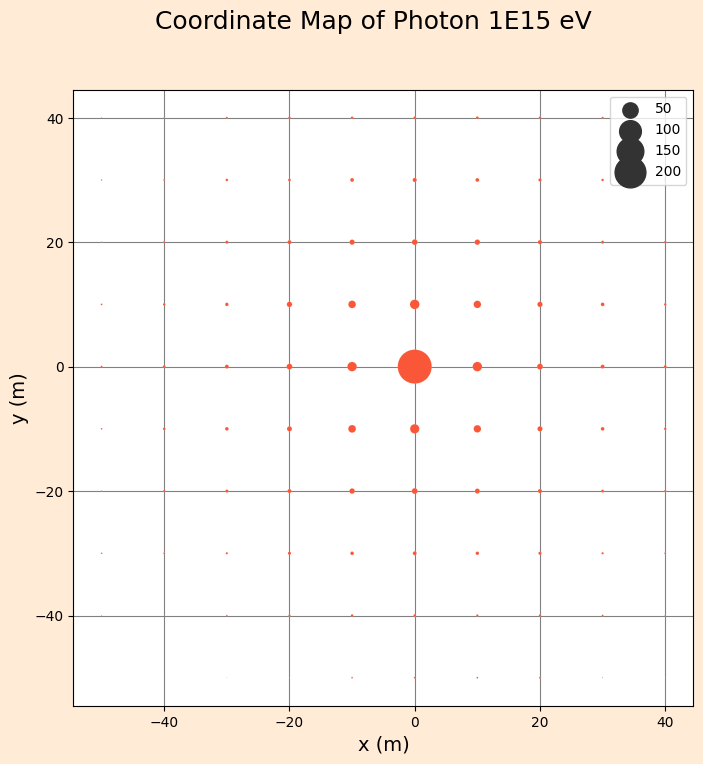

In [152]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
#fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs,
            sizes=(0, 600))
#sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#0D3B66',s = 50)

ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


#ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight')

In [192]:
# O primeiro índice é o trig do tanque, e o segundo é o evento. Apenas um exemplo
df2['count'][0][0]*x_det[0]+df2['count'][1][0]*x_det[1]+ df2['count'][2][0]*x_det[2]/(df2['count'][0][0]+df2['count'][1][0]+df2['count'][2][0])

-65.0

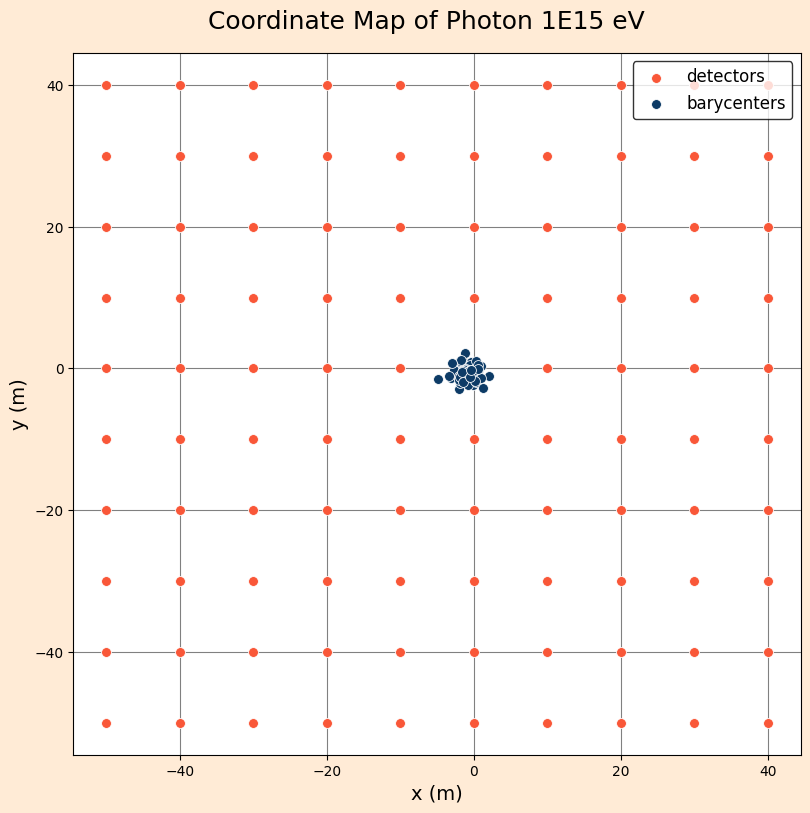

In [205]:
# Posição dos baricentros
x_b = [0] * len(trigs)
y_b = [0] * len(trigs)

for i in range(len(trigs)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (df2['count'][j][i]*x_det[j])
                numerator1 += (df2['count'][j][i]*y_det[j])
                denominator += (df2['count'][j][i])
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight')

In [214]:
# Criação de arquivo de dados para construir a função de distribuição lateral

r_b = []
for i in range(100):
    aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    r_b.append(aux)


df3 = df2.with_columns(
    pl.Series(name='x_b', values=x_b),
    pl.Series(name='y_b', values=y_b),
    pl.Series(name='r_b', values=r_b)
)
df3


TRIG,count,mean_count,x_b,y_b,r_b
str,list[i64],f64,f64,f64,f64
"""TRIG1""","[1, 0, … 1]",0.66,-0.688448,-0.525088,69.852674
"""TRIG2""","[0, 1, … 0]",0.67,-2.266667,-0.833333,61.977137
"""TRIG3""","[1, 0, … 0]",0.73,-0.549683,-1.458774,56.776508
"""TRIG4""","[1, 1, … 2]",0.89,-0.658949,-0.997329,52.681477
"""TRIG5""","[1, 0, … 3]",1.24,-0.520059,-0.713224,50.190194
"""TRIG6""","[3, 1, … 1]",1.32,2.060302,-1.055276,48.988068
"""TRIG7""","[3, 1, … 3]",1.29,0.089686,-0.538117,50.444943
"""TRIG8""","[5, 2, … 2]",1.44,-0.744619,-0.302501,53.853325
"""TRIG9""","[2, 0, … 0]",0.83,-1.267606,-0.788732,58.304477
